<a href="https://colab.research.google.com/github/Nadaramadan1/StarUnion_Projects/blob/main/Copy_of_Untitled25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading and Preprocessing Data

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np


(ds_all, info) = tfds.load('omniglot', split='all', as_supervised=False, with_info=True)

images = []
alphabets = []
chars = []

print("Indexing data...")
for example in ds_all:
    #resizes images to 64x64
    img = tf.image.resize(example['image'], [64, 64])

    #converts them to grayscale
    img = tf.image.rgb_to_grayscale(img)
    images.append(img.numpy())
    alphabets.append(example['alphabet'].numpy())
    chars.append(example['label'].numpy())

#normalizes pixel values
images = np.array(images) / 255.0
alphabets = np.array(alphabets)
chars = np.array(chars)
#splits the data into training and validation sets for both alphabet and character labels
from sklearn.model_selection import train_test_split
X_train, X_val, y_alb_train, y_alb_val, y_chr_train, y_chr_val = train_test_split(
    images, alphabets, chars, test_size=0.2, random_state=42, stratify=alphabets
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/4 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating small1 examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/omniglot/incomplete.0AP486_3.0.0/omniglot-small1.tfrecord*...:   0%|      …

Generating small2 examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/omniglot/incomplete.0AP486_3.0.0/omniglot-small2.tfrecord*...:   0%|      …

Dataset omniglot downloaded and prepared to /root/tensorflow_datasets/omniglot/3.0.0. Subsequent calls will reuse this data.
Indexing data...


In [ ]:
# from tensorflow.keras import layers, Model

# def build_robust_model():
#     inputs = layers.Input(shape=(64, 64, 1))


#     x = layers.RandomRotation(0.05)(inputs)

#     x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     x = layers.Flatten()(x)
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dropout(0.4)(x)


#     alphabet_out = layers.Dense(50, activation='softmax', name='alphabet_head')(x)
#     char_out = layers.Dense(1623, activation='softmax', name='char_head')(x)

#     return Model(inputs=inputs, outputs=[alphabet_out, char_out])

# model = build_robust_model()

# Build the Model and Data Augmentation

In [ ]:
from tensorflow.keras import layers, Model

def build_model():
    inputs = layers.Input(shape=(64, 64, 1))
    #rotate the images rondomly
    x = layers.RandomRotation(0.1)(inputs)
    #shift images rondomly
    x = layers.RandomTranslation(0.1, 0.1)(x)
    #zooms images rondomly
    x = layers.RandomZoom(0.1)(x)

    def residual_like_block(filters, x):
        #Two Conv2D layers (3x3 kernel) with padding='same' to preserve spatial dimensions.
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        #BatchNormalization layers after each convolution to stabilize training
        x = layers.BatchNormalization()(x)
        #ReLU activation functions
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        #MaxPooling2D((2, 2)) to reduce spatial dimensions (downsampling)
        x = layers.MaxPooling2D((2, 2))(x)

        #Dropout(0.2) to prevent overfitting
        x = layers.Dropout(0.2)(x)
        return x

    #extracting hierarchical features from the images
    x = residual_like_block(64, x)
    x = residual_like_block(128, x)
    x = residual_like_block(256, x)
    x = residual_like_block(512, x)

    #After the convolutional blocks, the output is flattened into a 1D vector
    x = layers.Flatten()(x)
    # fully connected Dense layer with 1024 units and ReLU activation processes the flattened features
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    alphabet_out = layers.Dense(50, activation='softmax', name='alphabet_head')(x)
    char_out = layers.Dense(1623, activation='softmax', name='char_head')(x)

    return Model(inputs=inputs, outputs=[alphabet_out, char_out])

model = build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 64, 64, 1) │          0 │ input_layer[0][0] │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 64, 64, 1) │          0 │ random_rotation[… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 64, 64, 1) │          0 │ random_translati… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        640 │ random_zoom[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_3[0][0]  

 Total params: 14,800,457 (56.46 MB)

 Trainable params: 14,794,569 (56.44 MB)

 Non-trainable params: 5,888 (23.00 KB)

# Model Training

In [ ]:
import numpy as np
from sklearn.utils import class_weight
import tensorflow as tf

# Calculate class weights for the character head
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
unique_char_labels = np.unique(y_chr_train)
char_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_char_labels,
    y=y_chr_train
)

# Convert the array of weights to a dictionary mapping class indices to weights
# Correctly map actual class labels to their weights
char_class_weights_dict = {label: weight for label, weight in zip(unique_char_labels, char_class_weights)}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'alphabet_head': tf.keras.losses.SparseCategoricalCrossentropy(),
        'char_head': tf.keras.losses.SparseCategoricalCrossentropy()
    },
    loss_weights={
        'alphabet_head': 0.3,
        'char_head': 0.7
    },
    metrics={
        'alphabet_head': 'accuracy',
        'char_head': 'accuracy'
    }
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        verbose=1,
        mode='min'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_char_head_accuracy',
        patience=20,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_checkpoint_{epoch:02d}_{val_char_head_accuracy:.4f}.keras',
        monitor='val_char_head_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Create sample weights for the character head based on the class weights
char_sample_weights = np.array([char_class_weights_dict[label] for label in y_chr_train])

history = model.fit(
    X_train,
    [y_alb_train, y_chr_train],
    validation_data=(X_val, [y_alb_val, y_chr_val]),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    # Apply class weights by passing them as sample weights for the specific output
    sample_weight=[np.ones(len(y_alb_train)), char_sample_weights]
)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - alphabet_head_accuracy: 0.4271 - alphabet_head_loss: 2.0413 - char_head_accuracy: 0.4397 - char_head_loss: 2.5295 - loss: 2.3830
Epoch 1: val_char_head_accuracy improved from None to 0.03055, saving model to best_model_checkpoint_01_0.0305.keras

Epoch 1: finished saving model to best_model_checkpoint_01_0.0305.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 71s 264ms/step - alphabet_head_accuracy: 0.4469 - alphabet_head_loss: 1.9591 - char_head_accuracy: 0.4737 - char_head_loss: 2.3618 - loss: 2.2421 - val_alphabet_head_accuracy: 0.1465 - val_alphabet_head_loss: 5.3250 - val_char_head_accuracy: 0.0305 - val_char_head_loss: 9.4147 - val_loss: 8.1873 - learning_rate: 0.0010
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - alphabet_head_accuracy: 0.4948 - alphabet_head_loss: 1.7502 - char_head_accuracy: 0.6011 - char_head_loss: 1.6073 - loss: 1.6502
Epoch 2: val_char_head_accuracy improved from 0.03055 to 0.53146, saving model to best_m

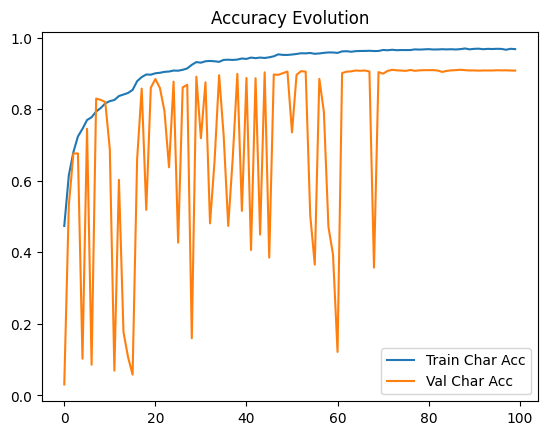

In [ ]:

model.save('Nada_Model_97_percent.keras')

import matplotlib.pyplot as plt
plt.plot(history.history['char_head_accuracy'], label='Train Char Acc')
plt.plot(history.history['val_char_head_accuracy'], label='Val Char Acc')
plt.title('Accuracy Evolution')
plt.legend()
plt.show()

# Evaluation

In [ ]:
evaluation_results = model.evaluate(
    X_val,
    {'alphabet_head': y_alb_val, 'char_head': y_chr_val}
)

print("Evaluation Results:")
print(f"Total Loss: {evaluation_results[0]:.4f}")
print(f"Alphabet Head Loss: {evaluation_results[1]:.4f}")
print(f"Character Head Loss: {evaluation_results[2]:.4f}")
print(f"Alphabet Head Accuracy: {evaluation_results[3]:.4f}")
print(f"Character Head Accuracy: {evaluation_results[4]:.4f}")

240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - alphabet_head_accuracy: 0.9104 - alphabet_head_loss: 0.3044 - char_head_accuracy: 0.9102 - char_head_loss: 0.3552 - loss: 0.3380
Evaluation Results:
Total Loss: 0.3380
Alphabet Head Loss: 0.3044
Character Head Loss: 0.3552
Alphabet Head Accuracy: 0.9104
Character Head Accuracy: 0.9102


# Classificarion Report

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the validation data
predictions = model.predict(X_val)
alphabet_predictions = predictions[0]
char_predictions = predictions[1]

# Convert probabilities to predicted class labels for alphabet head
predicted_alphabet_classes = np.argmax(alphabet_predictions, axis=1)

# Generate and print classification report for alphabet head
print("\n--- Classification Report for Alphabet Head ---")
print(classification_report(y_alb_val, predicted_alphabet_classes))

# Convert probabilities to predicted class labels for character head
predicted_char_classes = np.argmax(char_predictions, axis=1)

# Generate and print classification report for character head
print("\n--- Classification Report for Character Head ---")
print(classification_report(y_chr_val, predicted_char_classes))

240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step

--- Classification Report for Alphabet Head ---
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        80
           1       1.00      0.97      0.99        80
           2       0.94      0.88      0.91       116
           3       0.97      0.98      0.98       104
           4       0.96      0.88      0.92       164
           5       0.86      0.87      0.86       160
           6       0.95      0.97      0.96       104
           7       0.93      0.91      0.92       104
           8       0.92      0.88      0.90       104
           9       0.84      0.84      0.84       104
          10       0.97      0.99      0.98       192
          11       0.98      0.93      0.96       184
          12       0.90      0.80      0.85        56
          13       0.88      0.95      0.91       104
          14       0.86      0.85      0.86       136
          15       0.78      0.68      0.73 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Visual Error Analysis

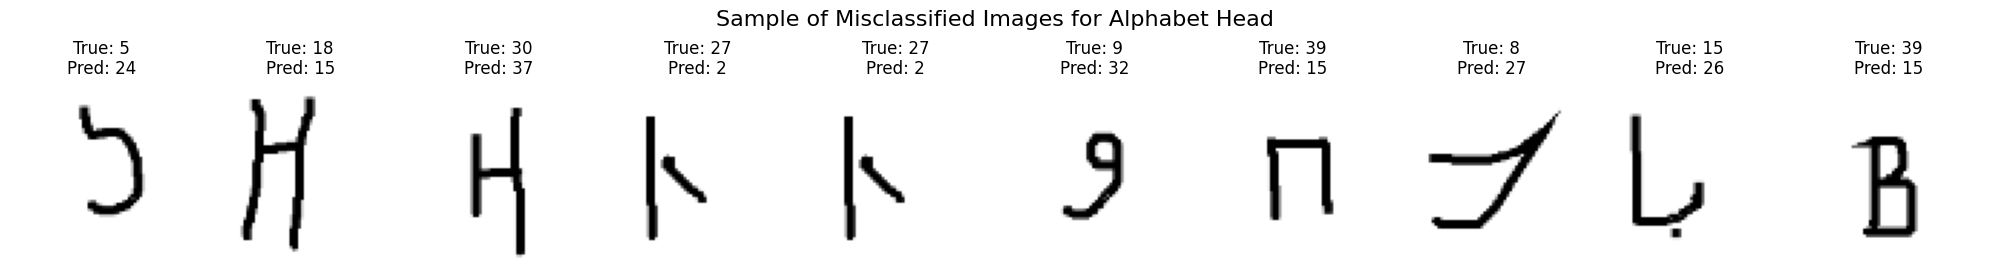

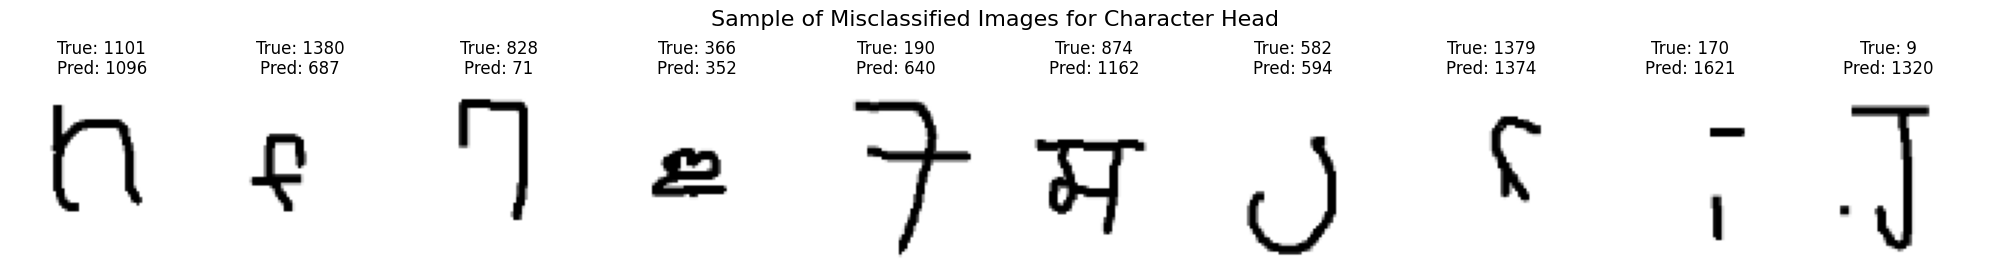

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_misclassified_images(images, true_labels, predicted_labels, head_name='Classification Head', n_samples=5):
    """
    Plots a sample of misclassified images.

    Args:
        images (np.array): Array of image data.
        true_labels (np.array): Array of true labels.
        predicted_labels (np.array): Array of predicted labels.
        head_name (str): Name of the classification head (e.g., 'Alphabet', 'Character').
        n_samples (int): Number of misclassified samples to display.
    """
    misclassified_indices = np.where(predicted_labels != true_labels)[0]

    if len(misclassified_indices) == 0:
        print(f"No misclassified images found for {head_name}.")
        return

    # Select a random subset of misclassified samples if there are more than n_samples
    display_indices = np.random.choice(misclassified_indices, min(len(misclassified_indices), n_samples), replace=False)

    plt.figure(figsize=(2 * n_samples, 3))
    for i, idx in enumerate(display_indices):
        plt.subplot(1, n_samples, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}")
        plt.axis('off')
    plt.suptitle(f"Sample of Misclassified Images for {head_name} Head", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Visualize misclassifications for Alphabet Head
plot_misclassified_images(X_val, y_alb_val, predicted_alphabet_classes, head_name='Alphabet', n_samples=10)

# Visualize misclassifications for Character Head
plot_misclassified_images(X_val, y_chr_val, predicted_char_classes, head_name='Character', n_samples=10)

# Confusion Matrix

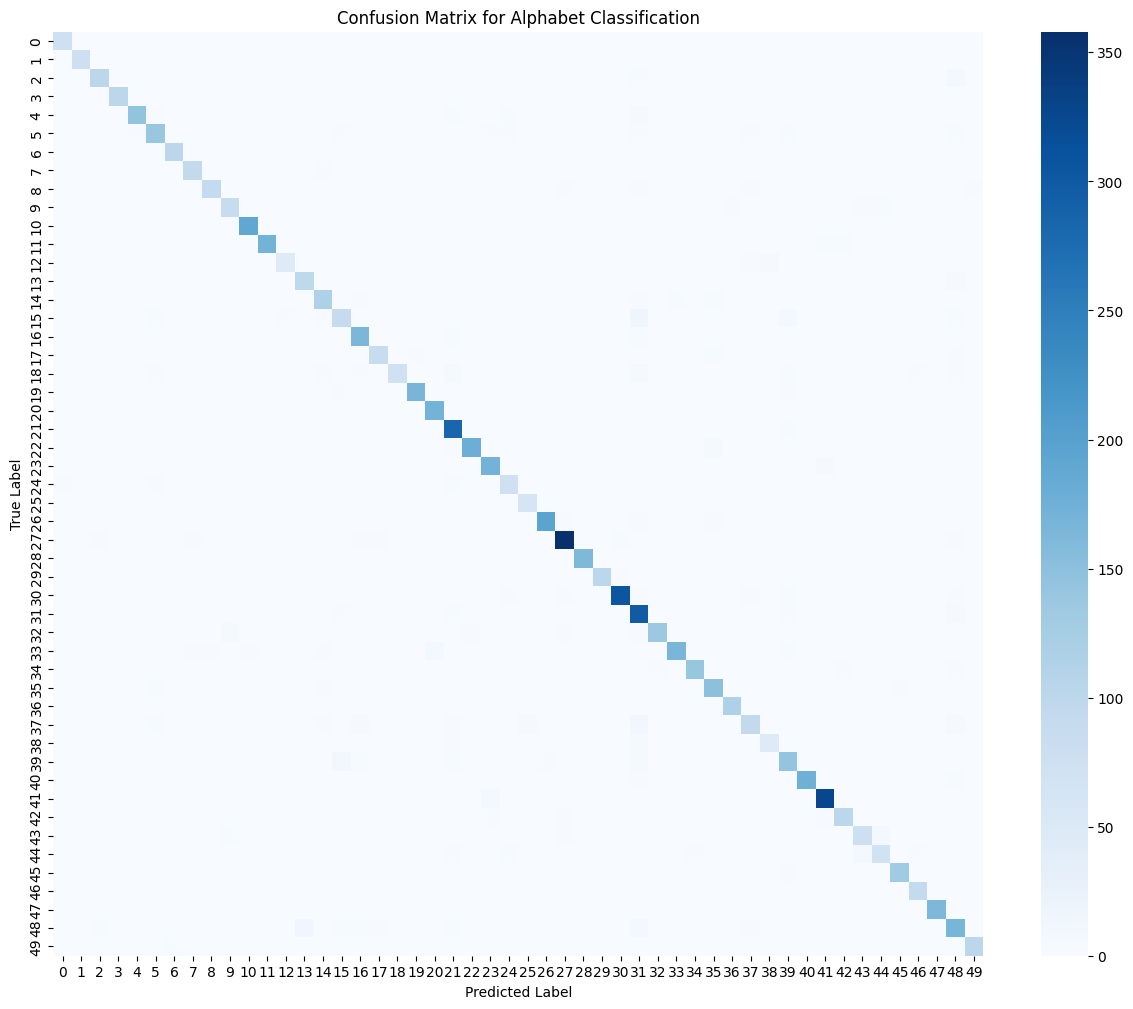

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for Alphabet Head
cm_alphabet = confusion_matrix(y_alb_val, predicted_alphabet_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_alphabet, annot=False, cmap='Blues', fmt='d')
plt.title('Confusion Matrix for Alphabet Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

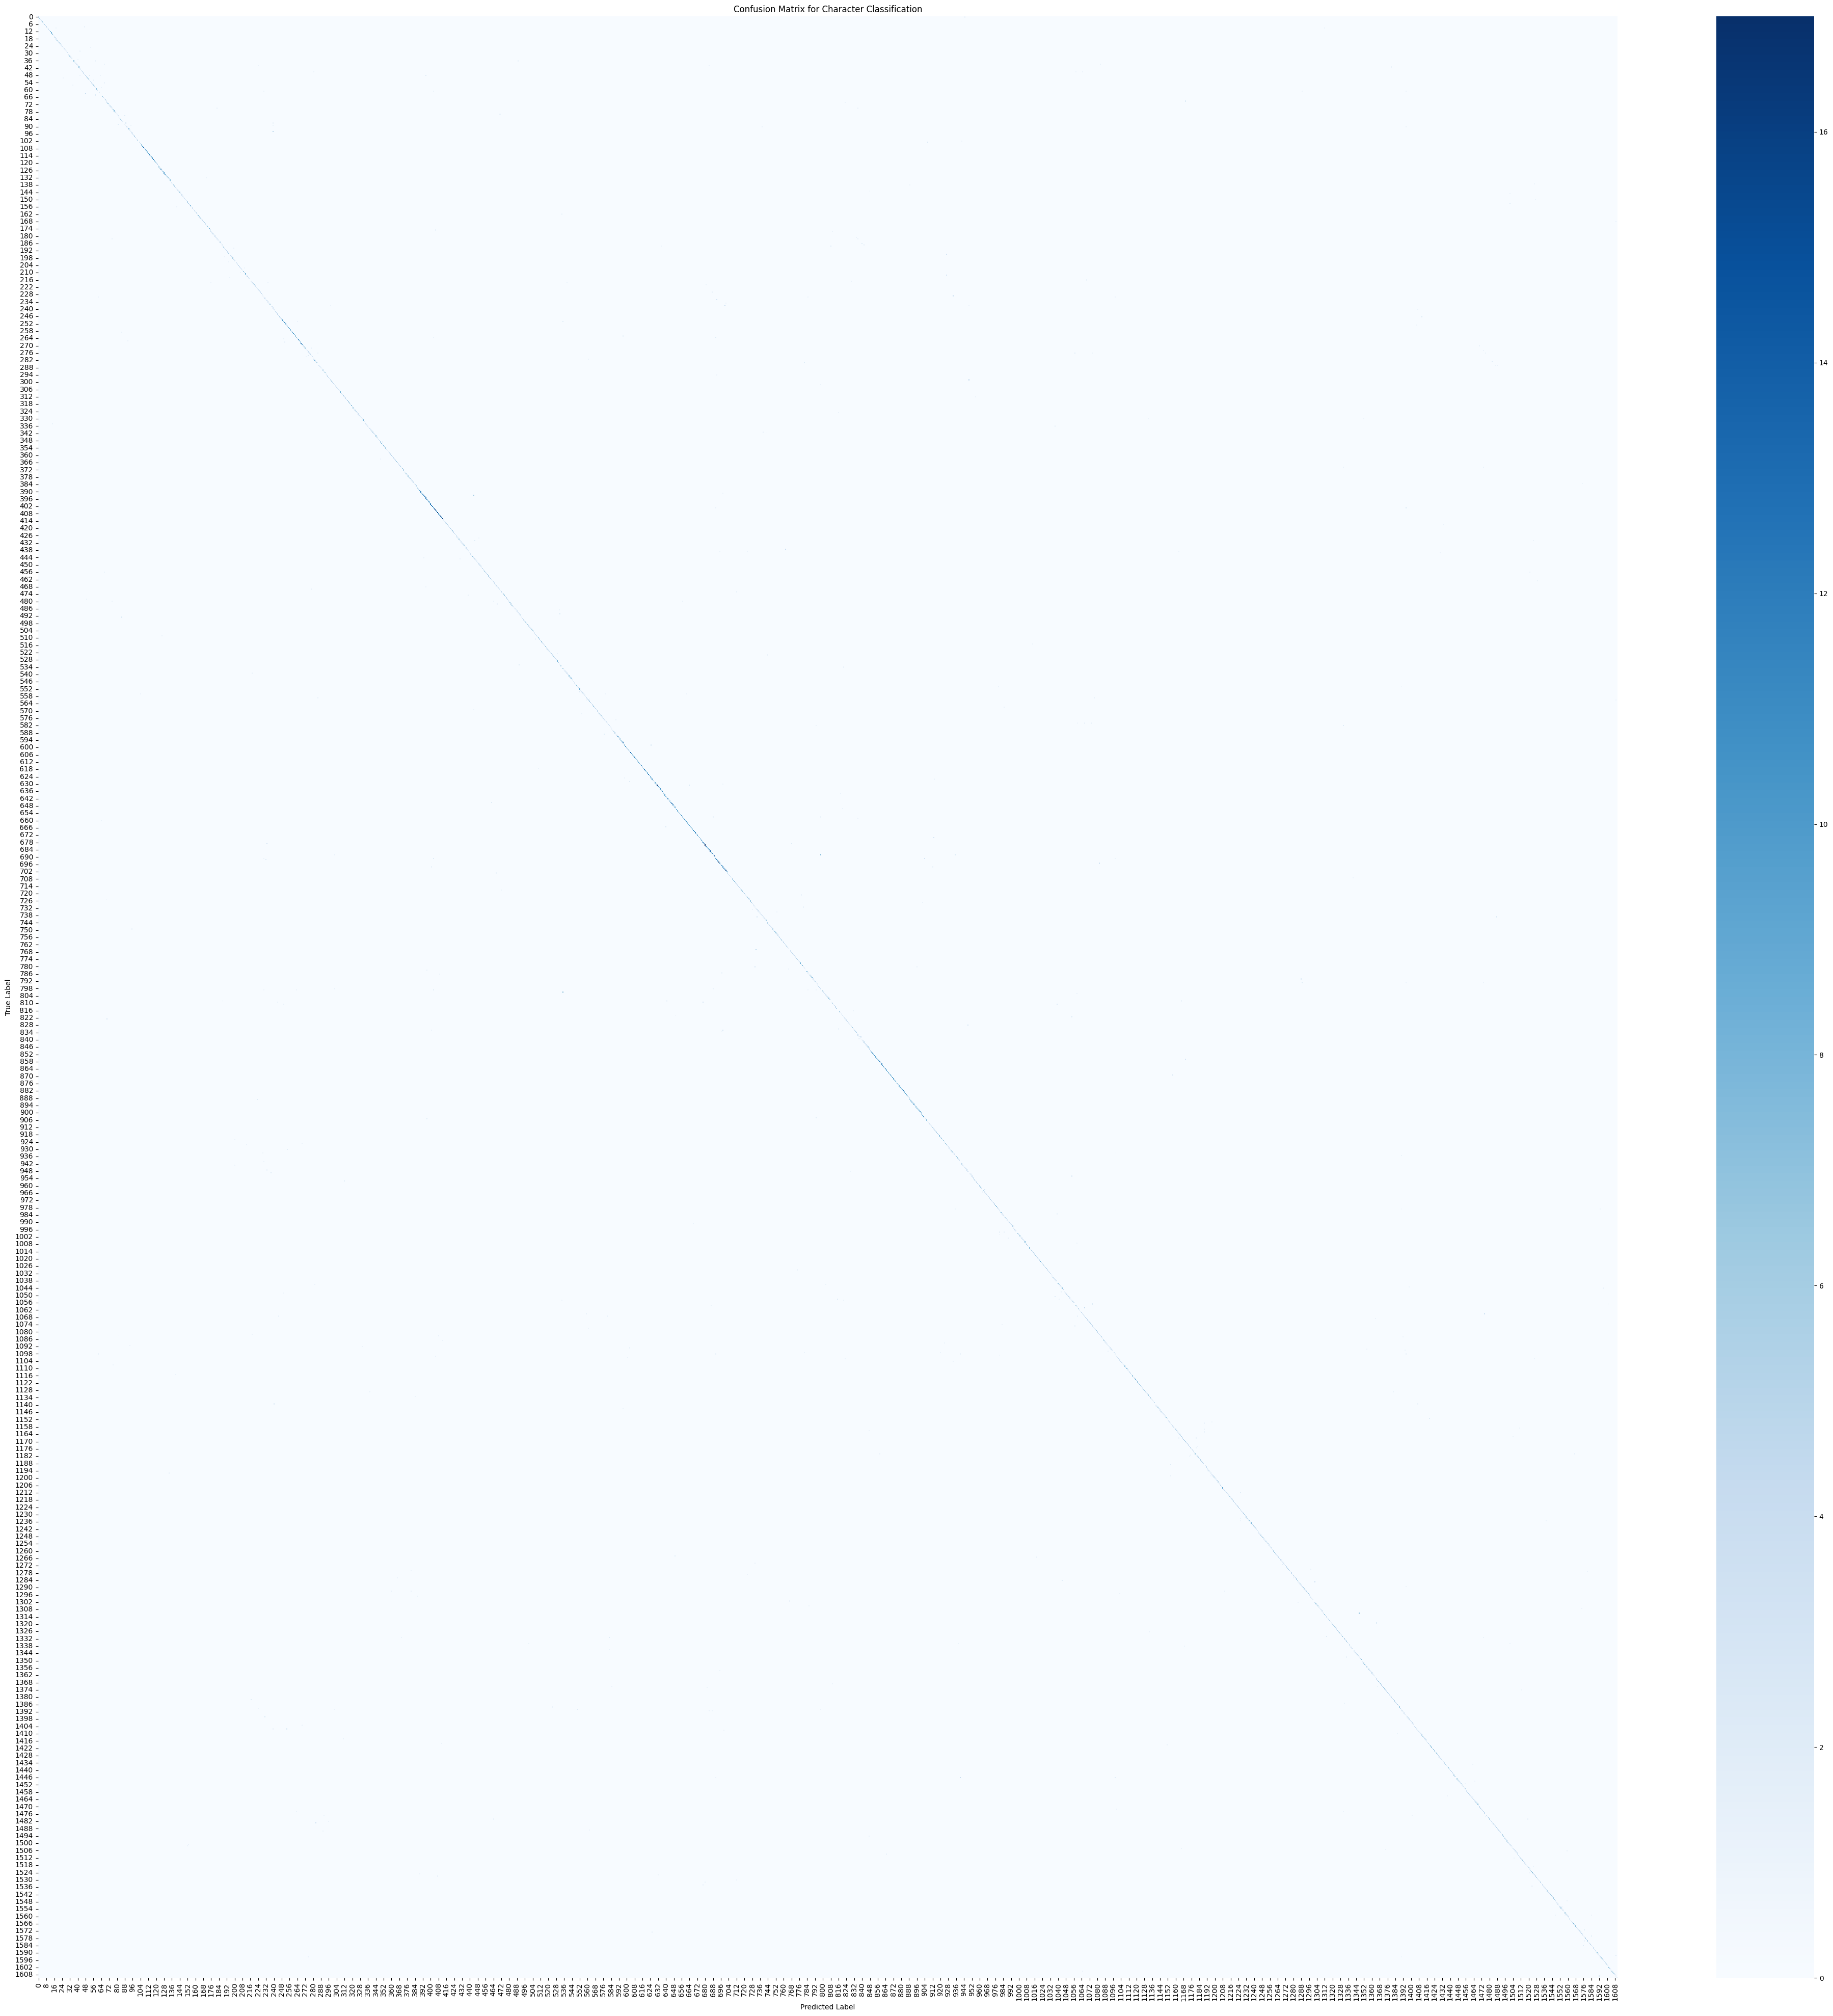

In [ ]:
# Generate confusion matrix for Character Head
cm_char = confusion_matrix(y_chr_val, predicted_char_classes)

plt.figure(figsize=(50, 50)) # Adjust figure size for many classes
sns.heatmap(cm_char, annot=False, cmap='Blues', fmt='d')
plt.title('Confusion Matrix for Character Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

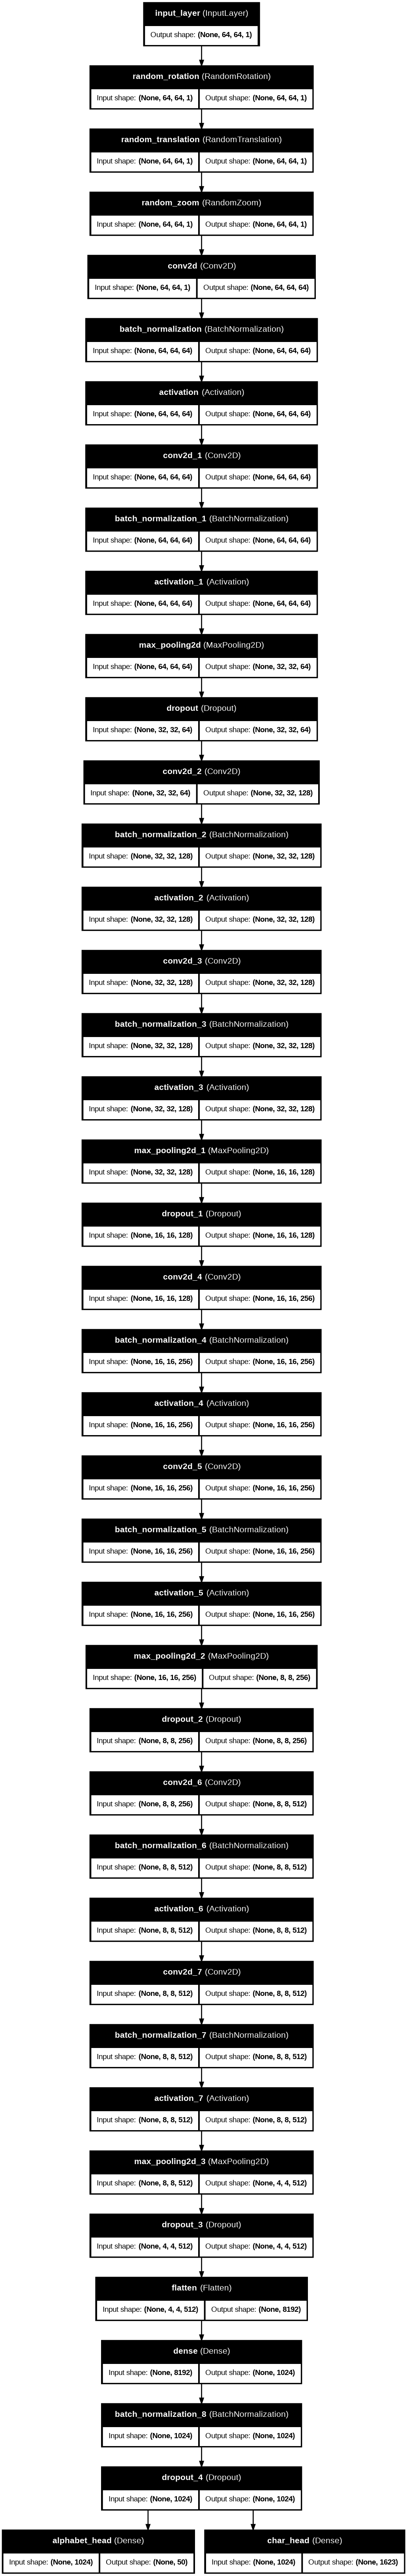

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model


plot_model(
    model,
    to_file='omniglot_architecture.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

from IPython.display import Image
Image(retina=True, filename='omniglot_architecture.png')

In [ ]:
model.save('omniglot_multi_output_v1.keras')

In [ ]:
from google.colab import files

files.download('omniglot_multi_output_v1.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np

def preprocess_raw_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (105, 105))
    img = cv2.bitwise_not(img)
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=(0, -1))

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpxkgqts99'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  List[TensorSpec(shape=(None, 50), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1623), dtype=tf.float32, name=None)]
Captures:
  138676317469776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676317469392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262848848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262849040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262848656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262846736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262848464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262847504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262850192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138676262850384: T

# Convert Model To Lighter Verion

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

tflite_model_path = 'model.tflite'

interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def predict_character(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (64, 64))

    # Ensure the image data type matches the TFLite model's input type
    # and normalize pixel values (0-255 to 0.0-1.0)
    img = img.astype(input_details[0]['dtype']) / 255.0

    # Add batch and channel dimensions: (1, 64, 64, 1)
    img = np.expand_dims(img, axis=(0, -1))

    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()


    # The output details match the model's outputs (alphabet_head, char_head)
    alphabet_output = interpreter.get_tensor(output_details[0]['index'])
    char_output = interpreter.get_tensor(output_details[1]['index'])

    alphabet_pred = np.argmax(alphabet_output, axis=1)
    char_pred = np.argmax(char_output, axis=1)

    return alphabet_pred[0], char_pred[0]

print("Inference function is ready with TFLite interpreter!")

Inference function is ready with TFLite interpreter!


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import numpy as np

def run_tflite_inference(input_data):

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()


    interpreter.set_tensor(input_details[0]['index'], input_data)

    interpreter.invoke()

    alphabet_output = interpreter.get_tensor(output_details[0]['index'])
    char_output = interpreter.get_tensor(output_details[1]['index'])

    return np.argmax(alphabet_output), np.argmax(char_output)

test_img = np.expand_dims(X_val[0], axis=0).astype(np.float32)
alpha_idx, char_idx = run_tflite_inference(test_img)

print(f" TFLite Prediction -> Alphabet: {alpha_idx}, Character: {char_idx}")

 TFLite Prediction -> Alphabet: 919, Character: 49


In [ ]:
def run_safe_tflite_inference(input_data):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()


    out_0 = interpreter.get_tensor(output_details[0]['index'])
    out_1 = interpreter.get_tensor(output_details[1]['index'])

    if out_0.shape[1] == 50:
        alphabet_logits, char_logits = out_0, out_1
    else:
        alphabet_logits, char_logits = out_1, out_0

    return np.argmax(alphabet_logits), np.argmax(char_logits)

alpha_idx, char_idx = run_safe_tflite_inference(test_img)
print(f" Corrected Prediction -> Alphabet: {alpha_idx}, Character: {char_idx}")

 Corrected Prediction -> Alphabet: 49, Character: 919


In [ ]:
alphabet_names = info.features['alphabet'].names
char_names = info.features['label'].names

print(f"Predicted Alphabet Name: {alphabet_names[alpha_idx]}")
print(f"Predicted Character Name: {char_names[char_idx]}")

Predicted Alphabet Name: ULOG
Predicted Character Name: Tifinagh_10


# Model Versioning

In [ ]:
!pip install mlflow pyngrok --quiet

import mlflow
import subprocess

get_ipython().system_raw("mlflow ui --port 5000 &")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 23.6 MB/s eta 0:00:00


In [ ]:
import mlflow
import mlflow.keras
from mlflow.models import infer_signature
import numpy as np


mlflow.keras.autolog(disable=True)

mlflow.set_experiment("Omniglot_MultiOutput_Project")

with mlflow.start_run(run_name="CNN_Fixed_v2"):

    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("initial_learning_rate", 0.001)
    mlflow.log_param("batch_size", 128)
    mlflow.log_param("epochs", 100)


    history = model.fit(
        X_train,
        {'alphabet_head': y_alb_train, 'char_head': y_chr_train},
        validation_data=(X_val, {'alphabet_head': y_alb_val, 'char_head': y_chr_val}),
        epochs=100,
        batch_size=128,
        callbacks=callbacks
    )


    for epoch in range(len(history.history['loss'])):
        mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
        mlflow.log_metric("train_alphabet_head_loss", history.history['alphabet_head_loss'][epoch], step=epoch)
        mlflow.log_metric("train_char_head_loss", history.history['char_head_loss'][epoch], step=epoch)
        mlflow.log_metric("train_alphabet_head_accuracy", history.history['alphabet_head_accuracy'][epoch], step=epoch)
        mlflow.log_metric("train_char_head_accuracy", history.history['char_head_accuracy'][epoch], step=epoch)

        mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
        mlflow.log_metric("val_alphabet_head_loss", history.history['val_alphabet_head_loss'][epoch], step=epoch)
        mlflow.log_metric("val_char_head_loss", history.history['val_char_head_loss'][epoch], step=epoch)
        mlflow.log_metric("val_alphabet_head_accuracy", history.history['val_alphabet_head_accuracy'][epoch], step=epoch)
        mlflow.log_metric("val_char_head_accuracy", history.history['val_char_head_accuracy'][epoch], step=epoch)


    input_sample = X_train[:1]

    output_sample = model.predict(input_sample)

    signature = infer_signature(input_sample, output_sample)


    mlflow.keras.log_model(
        model,
        artifact_path="model",
        signature=signature,
        registered_model_name="Omniglot_Stable_Model",
    )
    print("version saved")

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - alphabet_head_accuracy: 0.9365 - alphabet_head_loss: 0.1954 - char_head_accuracy: 0.9689 - char_head_loss: 0.0893 - loss: 0.1211
Epoch 1: val_char_head_accuracy did not improve from 0.91057
240/240 ━━━━━━━━━━━━━━━━━━━━ 63s 263ms/step - alphabet_head_accuracy: 0.9363 - alphabet_head_loss: 0.1938 - char_head_accuracy: 0.9690 - char_head_loss: 0.0889 - loss: 0.1204 - val_alphabet_head_accuracy: 0.9107 - val_alphabet_head_loss: 0.3053 - val_char_head_accuracy: 0.9098 - val_char_head_loss: 0.3541 - val_loss: 0.3391 - learning_rate: 1.9073e-09
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - alphabet_head_accuracy: 0.9352 - alphabet_head_loss: 0.1953 - char_head_accuracy: 0.9667 - char_head_loss: 0.0934 - loss: 0.1240
Epoch 2: val_char_head_accuracy did not improve from 0.91057
240/240 ━━━━━━━━━━━━━━━━━━━━ 62s 256ms/step - alphabet_head_accuracy: 0.9353 - alphabet_head_loss: 0.1944 - char_head_accuracy: 0.9678 - char_head_loss:

2026/03/19 18:54:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


version saved


Successfully registered model 'Omniglot_Stable_Model'.
Created version '1' of model 'Omniglot_Stable_Model'.


In [ ]:
import mlflow

# List all registered models
client = mlflow.tracking.MlflowClient()
registered_models = client.search_registered_models()

print("Registered Models in MLflow:")
for rm in registered_models:
    print(f"Name: {rm.name}")
    for mv in rm.latest_versions:
        print(f"  Version: {mv.version}, Stage: {mv.current_stage}")


Registered Models in MLflow:
Name: Omniglot_Stable_Model
  Version: 1, Stage: None


In [ ]:
import tensorflow as tf
import numpy as np

# Load the saved model
saved_model = tf.keras.models.load_model('omniglot_multi_output_v1.keras')

# Evaluate the loaded model on the validation data
evaluation_results_saved = saved_model.evaluate(
    X_val,
    {'alphabet_head': y_alb_val, 'char_head': y_chr_val}
)

print("\nEvaluation Results for the Saved Model ('omniglot_multi_output_v1.keras'):")
print(f"Total Loss: {evaluation_results_saved[0]:.4f}")
print(f"Alphabet Head Loss: {evaluation_results_saved[1]:.4f}")
print(f"Character Head Loss: {evaluation_results_saved[2]:.4f}")
print(f"Alphabet Head Accuracy: {evaluation_results_saved[3]:.4f}")
print(f"Character Head Accuracy: {evaluation_results_saved[4]:.4f}")

240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - alphabet_head_accuracy: 0.9104 - alphabet_head_loss: 0.3044 - char_head_accuracy: 0.9102 - char_head_loss: 0.3552 - loss: 0.3380

Evaluation Results for the Saved Model ('omniglot_multi_output_v1.keras'):
Total Loss: 0.3380
Alphabet Head Loss: 0.3044
Character Head Loss: 0.3552
Alphabet Head Accuracy: 0.9104
Character Head Accuracy: 0.9102


In [ ]:
from google.colab import files

files.download('/content/omniglot_architecture.png')
files.download('/content/omniglot_multi_output_v1.keras')
files.download('/content/model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_7977/3586855620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


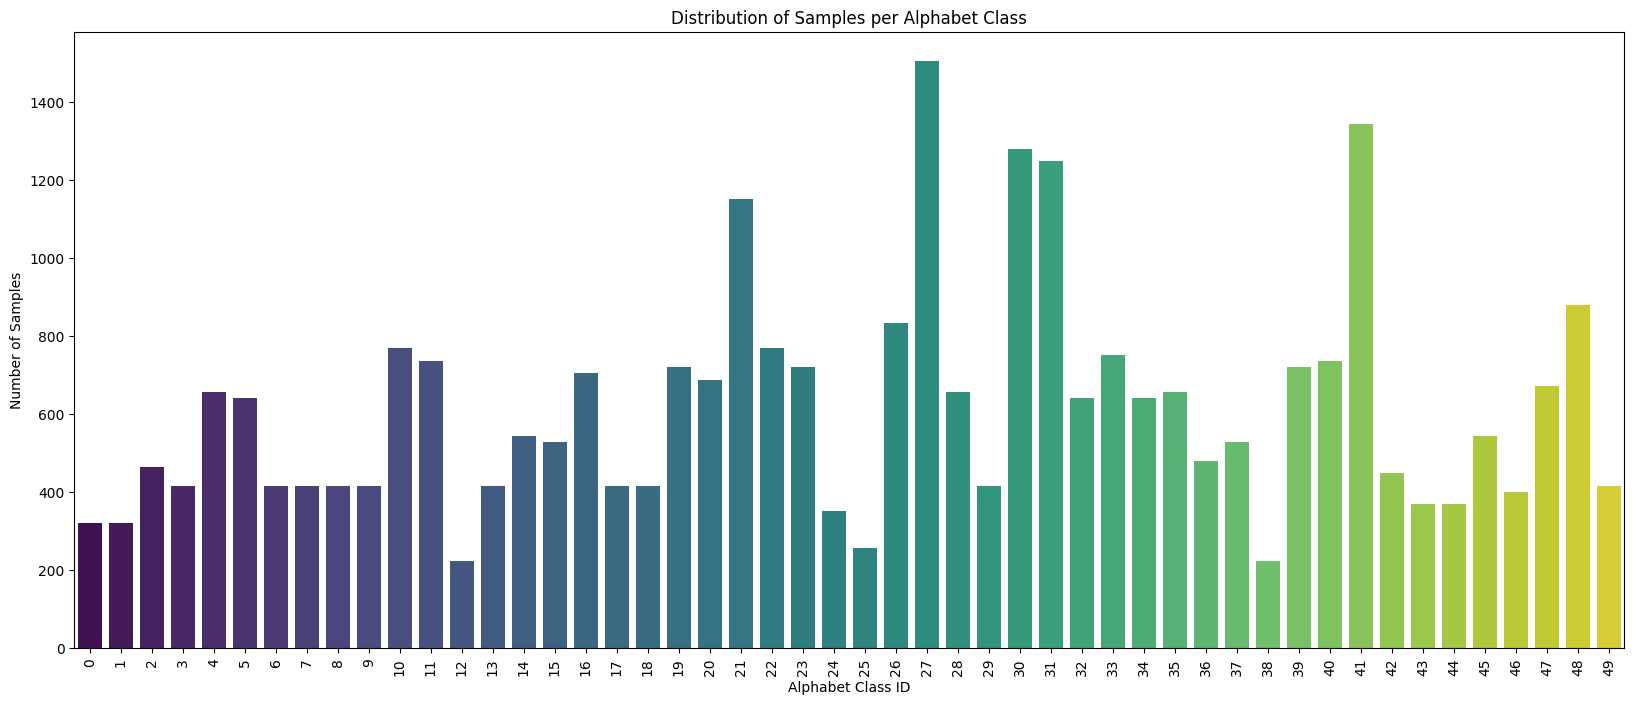

⚠️ weak alphapets [0, 1, 2, 3, 6, 7, 8, 9, 12, 13, 14, 15, 17, 18, 24, 25, 29, 36, 37, 38, 42, 43, 44, 45, 46, 49]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

counts = pd.Series(y_alb_train).value_counts().sort_index()

plt.figure(figsize=(20, 8))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Distribution of Samples per Alphabet Class")
plt.xlabel("Alphabet Class ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.show()

threshold = counts.mean()
weak_classes = counts[counts < threshold].index.tolist()
print(f"⚠️ weak alphapets {weak_classes}")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

y_pred_all = model.predict(X_val)
y_char_pred = np.argmax(y_pred_all[1], axis=1)

report = classification_report(y_chr_val, y_char_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()


weak_characters = df_report.iloc[:-3].copy()
weak_characters = weak_characters[weak_characters['f1-score'] < 0.50]

weak_characters = weak_characters.sort_values(by='f1-score')

print(f"found {len(weak_characters)} weak characters out of 1623.")
print(weak_characters[['precision', 'recall', 'f1-score', 'support']].head(20))

240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
found 85 weak characters out of 1623.
     precision  recall  f1-score  support
36         0.0     0.0       0.0      1.0
65         0.0     0.0       0.0      2.0
64         0.0     0.0       0.0      4.0
62         0.0     0.0       0.0      4.0
103        0.0     0.0       0.0      1.0
197        0.0     0.0       0.0      3.0
203        0.0     0.0       0.0      1.0
88         0.0     0.0       0.0      3.0
539        0.0     0.0       0.0      1.0
288        0.0     0.0       0.0      0.0
239        0.0     0.0       0.0      7.0
218        0.0     0.0       0.0      1.0
813        0.0     0.0       0.0      3.0
804        0.0     0.0       0.0      6.0
788        0.0     0.0       0.0      1.0
771        0.0     0.0       0.0      5.0
843        0.0     0.0       0.0      2.0
844        0.0     0.0       0.0      2.0
945        0.0     0.0       0.0      1.0
954        0.0     0.0       0.0      2.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
weak_alphabets = [0, 1, 2, 3, 6, 7, 8, 9, 12, 13, 14, 15, 17, 18, 24, 25, 29, 36, 37, 38, 42, 43, 44, 45, 46, 49]

weak_characters = [36, 65, 64, 62, 103, 197, 203, 88, 539, 288, 239, 218, 813, 804, 788, 771, 843, 844, 945, 954]

In [ ]:
def balance_dataset(X, y_alb, y_chr):
    X_balanced = [X]
    y_alb_balanced = [y_alb]
    y_chr_balanced = [y_chr]

    img_shape = X[0].shape

    for i in range(len(X)):
        if y_alb[i] in weak_alphabets or y_chr[i] in weak_characters:
            for _ in range(2):
                noise = np.random.normal(0, 0.01, img_shape)
                augmented_img = (X[i] + noise).reshape((1,) + img_shape)

                X_balanced.append(augmented_img)
                y_alb_balanced.append([y_alb[i]])
                y_chr_balanced.append([y_chr[i]])

    return np.vstack(X_balanced), np.concatenate(y_alb_balanced), np.concatenate(y_chr_balanced)

X_train_final, y_alb_train_final, y_chr_train_final = balance_dataset(X_train, y_alb_train, y_chr_train)
print(f"balanced data {len(X_train_final)}")

balanced data 51980


In [ ]:
from sklearn.utils import class_weight

alb_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_alb_train_final),
    y=y_alb_train_final
)
alb_weight_dict = dict(enumerate(alb_weights))